In [1]:
begin
    using Pkg
    dev_folder = joinpath(@__DIR__, "../Examples")
    Pkg.activate(dev_folder)
end
Threads.nthreads()

  Activating project at `~/Realizibility_index/BindingAndCatalysis.jl/Examples`


24

In [2]:
using LinearAlgebra
using SparseArrays
using GLMakie
using Revise
using BindingAndCatalysis # import the package

[ Info: Precompiling BindingAndCatalysis [b532a4b1-2c45-4c12-bcaf-8695372aa40c] (cache misses: include_dependency fsize change (4), wrong source (6), mismatched flags (8))


 Here we want to learn about toggle-switch network and how it have multistability

In [4]:
add_constrain_k = let 
        # γ, β
    F = [1  0  # :γ₁
         1  0  # :γ₂
         0  1  # :β₁
         0  1  # :β₂
         1  0  # :δ₁
         1  0] # :δ₂
    F0 = zeros(6)
    F, F0
end

model = let 
    #P1 P2 D1 D2 C1 C2
    N = [
     1 0 0 1 -1 0
     0 1 1 0 0 -1
         ]
    x_sym = [:P₁, :P₂, :D₁, :D₂, :C₁, :C₂]
    q_sym = [:tP₁, :tP₂, :tD₁, :tD₂]
    K_sym = [:K₁, :K₂]
    Bnc(;N, x_sym, q_sym, K_sym)
end

let 
    Π = diagm(ones(Int, 6))
    S = [-1 0 1 0 -1 0
          0 -1 0 1 0 -1]
    F, F0 = add_constrain_k
    update_catalysis!(model; Π, Γ=S, q_picked=[1,2], F, F0, k_sym=[:γ, :β])
end

match_regimes!(model)
n_bnc_regimes(model)


[ Info: q is reordered to make catalysis-involving species first


In [5]:
show_catalysis_dynamics(model)

4-element Vector{Symbolics.Equation}:
 Differential(t, 1)(tP₁) ~ -C₁*δ₁ + D₁*β₁ - P₁*γ₁
 Differential(t, 1)(tP₂) ~ -C₂*δ₂ + D₂*β₂ - P₂*γ₂
 Differential(t, 1)(tD₁) ~ 0
 Differential(t, 1)(tD₂) ~ 0

In [73]:
show_conservation(model)

4-element Vector{Symbolics.Equation}:
 tP₁ ~ C₁ + P₁
 tP₂ ~ C₂ + P₂
 tD₁ ~ C₂ + D₁
 tD₂ ~ C₁ + D₂

In [74]:
show_equilibrium(model)

2-element Vector{Symbolics.Equation}:
 K₁ ~ (D₂*P₁) / C₁
 K₂ ~ (D₁*P₂) / C₂

As the typically we have relationship between catalysis constants, for example, degradation speeds are equal for a same protein


In [6]:
# [:γ₁, :γ₂, :β₁, :β₂, :δ₁, :δ₂] = F([:γ₁, :γ₂, :β₁, :β₂, :δ₁, :δ₂]
add_constrain_k = let 
        #γ, β
    F = [1  0  # :γ₁
         1  0 # :γ₂
         0  1  # :β₁
         0  1 # :β₂
         1  0      # :δ₁
         1  0] # :δ₂
    F0 = zeros(6)
    F,F0
end 

([1 0; 1 0; … ; 1 0; 1 0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

In [7]:
rgms = get_bnc_regimes(model) # With affine k constraints, the public Bnc regimes are already filtered.
length(rgms)


[ Info: ---------------------Start finding all regimes--------------------
[ Info: Finished, with 16 regimes found and 16 asymptotic regimes.
[ Info: 2.Building x-neighbor regime graph...
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
[ Info: 3.Building regime objects...
[ Info: 4.Propagating affine data and deferred nullity labels...
[ Info: 5.Calculating qK change directions on the regime graph...
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
[ Info: Finished.
[ Info: ---------------------Start finding all vertices--------------------
[ Info: Finished, with 4 catalysis vertices found and 4 asymptotic vertices.
[ Info: 3.Building Regimes...
[ Info: Matching Catalysis Regimes and Binding Regimes to build BncRegimes...
[ Info: Finished matching BncRegimes.
[ Info: Initializing BncRegimes...
┌ Warning: Inconsistent singular BncRegime H_inner directions found during graph propagation: 24 cases. See `_initialize_inner_affine_by_graph!` for

64-element Vector{BindingAndCatalysis.BncRegime}:
 BncRegime(bind=[1, 2, 3, 4], cat=[3, 4, 1, 2], ss=([1, 2, 3, 4], [3, 4, 1, 2]), nullity=0, asymptotic=true)
 BncRegime(bind=[1, 2, 3, 5], cat=[3, 4, 1, 2], ss=([1, 2, 3, 5], [3, 4, 1, 2]), nullity=0, asymptotic=true)
 BncRegime(bind=[1, 2, 6, 4], cat=[3, 4, 1, 2], ss=([1, 2, 6, 4], [3, 4, 1, 2]), nullity=0, asymptotic=true)
 BncRegime(bind=[1, 2, 6, 5], cat=[3, 4, 1, 2], ss=([1, 2, 6, 5], [3, 4, 1, 2]), nullity=1, asymptotic=true)
 BncRegime(bind=[1, 6, 3, 4], cat=[3, 4, 1, 2], ss=([1, 6, 3, 4], [3, 4, 1, 2]), nullity=0, asymptotic=true)
 BncRegime(bind=[1, 6, 3, 5], cat=[3, 4, 1, 2], ss=([1, 6, 3, 5], [3, 4, 1, 2]), nullity=0, asymptotic=true)
 BncRegime(bind=[1, 6, 6, 4], cat=[3, 4, 1, 2], ss=([1, 6, 6, 4], [3, 4, 1, 2]), nullity=0, asymptotic=true)
 BncRegime(bind=[1, 6, 6, 5], cat=[3, 4, 1, 2], ss=([1, 6, 6, 5], [3, 4, 1, 2]), nullity=1, asymptotic=true)
 BncRegime(bind=[5, 2, 3, 4], cat=[3, 4, 1, 2], ss=([5, 2, 3, 4], [3, 4, 1, 2]

The constraints on k are now passed directly to `update_catalysis!`. The xk/qKk/wKk conditions and affine maps below are already in the reduced k coordinates, and infeasible binding/catalysis dominance combinations have been filtered out.


In [8]:
# F/F0 is handled during model initialization.
# Check that every xk condition is expressed in (x, γ, β), not the six old k variables.
all(size(get_C_C0_xk(rgm)[1], 2) == model.n + get_catalysis_network(model).n_k for rgm in rgms)


filter_regimes_by_xk (generic function with 1 method)

In [9]:
rgms_filtered = rgms
length(rgms_filtered)


16-element Vector{BindingAndCatalysis.BncRegime}:
 BncRegime(bind=[1, 2, 3, 4], cat=[3, 4, 1, 2], ss=([1, 2, 3, 4], [3, 4, 1, 2]), nullity=0, asymptotic=true)
 BncRegime(bind=[1, 2, 3, 5], cat=[3, 4, 1, 2], ss=([1, 2, 3, 5], [3, 4, 1, 2]), nullity=0, asymptotic=true)
 BncRegime(bind=[1, 2, 6, 4], cat=[3, 4, 1, 2], ss=([1, 2, 6, 4], [3, 4, 1, 2]), nullity=0, asymptotic=true)
 BncRegime(bind=[1, 2, 6, 5], cat=[3, 4, 1, 2], ss=([1, 2, 6, 5], [3, 4, 1, 2]), nullity=1, asymptotic=true)
 BncRegime(bind=[1, 6, 3, 4], cat=[3, 4, 1, 6], ss=([1, 6, 3, 4], [3, 4, 1, 6]), nullity=0, asymptotic=true)
 BncRegime(bind=[1, 6, 3, 5], cat=[3, 4, 1, 6], ss=([1, 6, 3, 5], [3, 4, 1, 6]), nullity=0, asymptotic=true)
 BncRegime(bind=[1, 6, 6, 4], cat=[3, 4, 1, 6], ss=([1, 6, 6, 4], [3, 4, 1, 6]), nullity=1, asymptotic=true)
 BncRegime(bind=[1, 6, 6, 5], cat=[3, 4, 1, 6], ss=([1, 6, 6, 5], [3, 4, 1, 6]), nullity=0, asymptotic=true)
 BncRegime(bind=[5, 2, 3, 4], cat=[3, 4, 5, 2], ss=([5, 2, 3, 4], [3, 4, 5, 2]

Only 16 Bnc regimes are left after filtering by the reduced k dominance conditions, so no post-hoc mutation of regime conditions or affine maps is needed.


In [10]:
# wKk conditions are also expressed in the reduced coordinates (w, K, γ, β).
all(size(get_C_C0_nullity_wKk(rgm)[1], 2) == length(wKk_sym(model)) for rgm in rgms_filtered)


add_constrain_k_to_regime! (generic function with 1 method)

In [11]:
all(is_feasible, rgms_filtered)


In [12]:
wKk_sym(model)


2-element Vector{Symbolics.Num}:
 γ
 β

a test to see now indeed we can freely analyze the regimes

In [13]:
rgm_example = rgms_filtered[1]

BncRegime
  dominant mode: bind=[1, 2, 3, 4], cat=[3, 4, 1, 2], ss=([1, 2, 3, 4], [3, 4, 1, 2])
  nullity: 0
  asymptotic: true

In [14]:
show_expression_x(rgm_example)

6-element Vector{Symbolics.Equation}:
 P₁ ~ (tD₁*β) / γ
 P₂ ~ (tD₂*β) / γ
 D₁ ~ tD₁
 D₂ ~ tD₂
 C₁ ~ (tD₁*tD₂*β) / (K₁*γ)
 C₂ ~ (tD₁*tD₂*β) / (K₂*γ)

In [15]:
show_expression_qcat(rgm_example)

2-element Vector{Symbolics.Equation}:
 tP₁ ~ (tD₁*β) / γ
 tP₂ ~ (tD₂*β) / γ

In [16]:
# keep only the full dimentional regimes
rgms_fulldim= filter(rgms_filtered) do rgm
    !is_singular(rgm)
end

11-element Vector{BindingAndCatalysis.BncRegime}:
 BncRegime(bind=[1, 2, 3, 4], cat=[3, 4, 1, 2], ss=([1, 2, 3, 4], [3, 4, 1, 2]), nullity=0, asymptotic=true)
 BncRegime(bind=[1, 2, 3, 5], cat=[3, 4, 1, 2], ss=([1, 2, 3, 5], [3, 4, 1, 2]), nullity=0, asymptotic=true)
 BncRegime(bind=[1, 2, 6, 4], cat=[3, 4, 1, 2], ss=([1, 2, 6, 4], [3, 4, 1, 2]), nullity=0, asymptotic=true)
 BncRegime(bind=[1, 6, 3, 4], cat=[3, 4, 1, 6], ss=([1, 6, 3, 4], [3, 4, 1, 6]), nullity=0, asymptotic=true)
 BncRegime(bind=[1, 6, 3, 5], cat=[3, 4, 1, 6], ss=([1, 6, 3, 5], [3, 4, 1, 6]), nullity=0, asymptotic=true)
 BncRegime(bind=[1, 6, 6, 5], cat=[3, 4, 1, 6], ss=([1, 6, 6, 5], [3, 4, 1, 6]), nullity=0, asymptotic=true)
 BncRegime(bind=[5, 2, 3, 4], cat=[3, 4, 5, 2], ss=([5, 2, 3, 4], [3, 4, 5, 2]), nullity=0, asymptotic=true)
 BncRegime(bind=[5, 2, 6, 4], cat=[3, 4, 5, 2], ss=([5, 2, 6, 4], [3, 4, 5, 2]), nullity=0, asymptotic=true)
 BncRegime(bind=[5, 2, 6, 5], cat=[3, 4, 5, 2], ss=([5, 2, 6, 5], [3, 4, 5, 2]

In [17]:
# sort the regimes by stability
sort!(rgms_fulldim, by = x -> is_stable(x) ? 0 : 1)

11-element Vector{BindingAndCatalysis.BncRegime}:
 BncRegime(bind=[1, 2, 3, 4], cat=[3, 4, 1, 2], ss=([1, 2, 3, 4], [3, 4, 1, 2]), nullity=0, asymptotic=true)
 BncRegime(bind=[1, 2, 3, 5], cat=[3, 4, 1, 2], ss=([1, 2, 3, 5], [3, 4, 1, 2]), nullity=0, asymptotic=true)
 BncRegime(bind=[1, 2, 6, 4], cat=[3, 4, 1, 2], ss=([1, 2, 6, 4], [3, 4, 1, 2]), nullity=0, asymptotic=true)
 BncRegime(bind=[1, 6, 3, 4], cat=[3, 4, 1, 6], ss=([1, 6, 3, 4], [3, 4, 1, 6]), nullity=0, asymptotic=true)
 BncRegime(bind=[1, 6, 3, 5], cat=[3, 4, 1, 6], ss=([1, 6, 3, 5], [3, 4, 1, 6]), nullity=0, asymptotic=true)
 BncRegime(bind=[5, 2, 3, 4], cat=[3, 4, 5, 2], ss=([5, 2, 3, 4], [3, 4, 5, 2]), nullity=0, asymptotic=true)
 BncRegime(bind=[5, 2, 6, 4], cat=[3, 4, 5, 2], ss=([5, 2, 6, 4], [3, 4, 5, 2]), nullity=0, asymptotic=true)
 BncRegime(bind=[5, 6, 3, 4], cat=[3, 4, 5, 6], ss=([5, 6, 3, 4], [3, 4, 5, 6]), nullity=0, asymptotic=true)
 BncRegime(bind=[1, 6, 6, 5], cat=[3, 4, 1, 6], ss=([1, 6, 6, 5], [3, 4, 1, 6]

In [18]:
ps = get_polyhedron.(rgms_fulldim)

11-element Vector{CDDLib.Polyhedron{Float64}}:
 HalfSpace([1.0, 0.0, 0.0, -1.0, 0.0, 0.0], 0.0) ∩ HalfSpace([0.0, 1.0, 0.0, -1.0, -1.0, 1.0], 0.0) ∩ HalfSpace([1.0, 0.0, -1.0, 0.0, -1.0, 1.0], 0.0) ∩ HalfSpace([0.0, 1.0, -1.0, 0.0, 0.0, 0.0], 0.0)
 HalfSpace([1.0, 0.0, 0.0, -1.0, 0.0, 0.0], 0.0) ∩ HalfSpace([-1.0, 1.0, 1.0, -1.0, 0.0, 0.0], 0.0) ∩ HalfSpace([-1.0, 0.0, 1.0, 0.0, 1.0, -1.0], 0.0) ∩ HalfSpace([-1.0, 1.0, 0.0, 0.0, 1.0, -1.0], 0.0)
 HalfSpace([1.0, -1.0, 0.0, 0.0, 1.0, -1.0], 0.0) ∩ HalfSpace([0.0, -1.0, 0.0, 1.0, 1.0, -1.0], 0.0) ∩ HalfSpace([1.0, -1.0, -1.0, 1.0, 0.0, 0.0], 0.0) ∩ HalfSpace([0.0, 1.0, -1.0, 0.0, 0.0, 0.0], 0.0)
 HalfSpace([-1.0, 1.0, 0.0, 0.0, -1.0, 1.0], 0.0) ∩ HalfSpace([1.0, 0.0, -1.0, 0.0, -1.0, 1.0], 0.0) ∩ HalfSpace([0.0, 1.0, -1.0, 0.0, 0.0, 0.0], 0.0) ∩ HalfSpace([-1.0, 0.0, 0.0, 1.0, 0.0, 0.0], 0.0)
 HalfSpace([-2.0, 1.0, 1.0, 0.0, 0.0, 0.0], 0.0) ∩ HalfSpace([-1.0, 0.0, 1.0, 0.0, 1.0, -1.0], 0.0) ∩ HalfSpace([-1.0, 1.0, 0.0, 0.0, 1.0, -1.0], 0

In [19]:
function pairwise_intersection(ps)
    M = Matrix{Polyhedron}(undef, length(ps), length(ps))
    for i in 1:length(ps)
        for j in 1:length(ps)
            if i == j
                M[i, j] = ps[i]
            else
                p_intersection = intersect(ps[i], ps[j])
                detecthlinearity!(p_intersection)
                removehredundancy!(p_intersection)
                M[i, j] = p_intersection
            end
        end
    end
    return M
end

pairwise_intersection (generic function with 1 method)

In [20]:
M_poly = pairwise_intersection(ps)

11×11 Matrix{Polyhedron}:
 HalfSpace([1.0, 0.0, 0.0, -1.0, 0.0, 0.0], 0.0) ∩ HalfSpace([0.0, 1.0, 0.0, -1.0, -1.0, 1.0], 0.0) ∩ HalfSpace([1.0, 0.0, -1.0, 0.0, -1.0, 1.0], 0.0) ∩ HalfSpace([0.0, 1.0, -1.0, 0.0, 0.0, 0.0], 0.0)        …  HyperPlane([1.0, 0.0, 0.0, -1.0, 0.0, 0.0], 0.0) ∩ HyperPlane([0.0, 1.0, 0.0, -1.0, -1.0, 1.0], 0.0) ∩ HyperPlane([1.0, 0.0, -1.0, 0.0, -1.0, 1.0], 0.0) ∩ HyperPlane([0.0, 1.0, -1.0, 0.0, 0.0, 0.0], 0.0)
 HyperPlane([-1.0, 0.0, 1.0, 0.0, 1.0, -1.0], 0.0) ∩ HalfSpace([1.0, 0.0, 0.0, -1.0, 0.0, 0.0], 0.0) ∩ HalfSpace([0.0, 1.0, 0.0, -1.0, -1.0, 1.0], 0.0) ∩ HalfSpace([0.0, 1.0, -1.0, 0.0, 0.0, 0.0], 0.0)          HyperPlane([1.0, 0.0, 0.0, -1.0, 0.0, 0.0], 0.0) ∩ HyperPlane([-1.0, 1.0, 0.0, 0.0, 1.0, -1.0], 0.0) ∩ HalfSpace([1.0, -1.0, 0.0, 0.0, 1.0, -1.0], 0.0) ∩ HalfSpace([-1.0, 0.0, 1.0, 0.0, -1.0, 1.0], 0.0)
 HyperPlane([0.0, -1.0, 0.0, 1.0, 1.0, -1.0], 0.0) ∩ HalfSpace([1.0, 0.0, 0.0, -1.0, 0.0, 0.0], 0.0) ∩ HalfSpace([1.0, 0.0, -1.0, 0.0, -1.0, 1.0]

In [21]:
sparse((dim.(M_poly)) .==6)

11×11 SparseMatrixCSC{Bool, Int64} with 33 stored entries:
 1  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅
 ⋅  1  ⋅  ⋅  ⋅  ⋅  1  ⋅  ⋅  1  ⋅
 ⋅  ⋅  1  ⋅  1  ⋅  ⋅  ⋅  1  ⋅  ⋅
 ⋅  ⋅  ⋅  1  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅
 ⋅  ⋅  1  ⋅  1  ⋅  1  ⋅  1  1  1
 ⋅  ⋅  ⋅  ⋅  ⋅  1  ⋅  ⋅  ⋅  ⋅  ⋅
 ⋅  1  ⋅  ⋅  1  ⋅  1  ⋅  1  1  1
 ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  1  ⋅  ⋅  ⋅
 ⋅  ⋅  1  ⋅  1  ⋅  1  ⋅  1  ⋅  ⋅
 ⋅  1  ⋅  ⋅  1  ⋅  1  ⋅  ⋅  1  ⋅
 ⋅  ⋅  ⋅  ⋅  1  ⋅  1  ⋅  ⋅  ⋅  1

In [22]:
stb_flag = is_stable.(rgms_fulldim)

11-element BitVector:
 1
 1
 1
 1
 1
 1
 1
 1
 0
 0
 0

In [23]:
q = sparse((dim.(M_poly[stb_flag,stb_flag])) .==6)

8×8 SparseMatrixCSC{Bool, Int64} with 14 stored entries:
 1  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅
 ⋅  1  ⋅  ⋅  ⋅  ⋅  1  ⋅
 ⋅  ⋅  1  ⋅  1  ⋅  ⋅  ⋅
 ⋅  ⋅  ⋅  1  ⋅  ⋅  ⋅  ⋅
 ⋅  ⋅  1  ⋅  1  ⋅  1  ⋅
 ⋅  ⋅  ⋅  ⋅  ⋅  1  ⋅  ⋅
 ⋅  1  ⋅  ⋅  1  ⋅  1  ⋅
 ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  1

In [24]:
pairs = let
    pairs = Vector{Vector{Int}}(undef,0)
    I,J,V = findnz(q)
    for (i,j,v) in zip(I,J,V)
        if i<j && v != 0
            push!(pairs, [i,j])
        end
    end
    pairs
end

3-element Vector{Vector{Int64}}:
 [3, 5]
 [2, 7]
 [5, 7]

So we have three regimes pairs have intersection, and let's evaluate each combination

The first combination is regime 3 and regime 5

In [68]:
r1_idx , r2_idx = pairs[1]
p_intersect1 = M_poly[r1_idx,r2_idx]
show_condition_poly(p_intersect1,syms=wKk_sym(model))

4-element Vector{Symbolics.Num}:
    (tD₂*β) > (tD₁*γ)
  (K₁*tD₂) > (K₂*tD₁)
             K₁ > tD₂
 (tD₁^2.0) > (K₁*tD₂)

In [82]:
sum(get_volumes(unstable_rgms))

Volume(Mean=6.212e-02, STD=1.853e-04, RelError=0.30%)

In [75]:
p_intersects = [M_poly[pairs[i]...] for i in 1:length(pairs)]

3-element Vector{CDDLib.Polyhedron{Float64}}:
 HalfSpace([1.0, -1.0, 0.0, 0.0, 1.0, -1.0], 0.0) ∩ HalfSpace([1.0, -1.0, -1.0, 1.0, 0.0, 0.0], 0.0) ∩ HalfSpace([0.0, 1.0, -1.0, 0.0, 0.0, 0.0], 0.0) ∩ HalfSpace([-2.0, 1.0, 1.0, 0.0, 0.0, 0.0], 0.0) : convexhull([0.0, 0.0, 0.0, 0.0, 0.0, 0.0]) + convexhull(Line([1.0, 1.0, 1.0, 1.0, 0.0, 0.0]), Line([0.0, 0.0, 0.0, 0.0, 1.0, 1.0])) + convexhull(Ray([0.0, 0.0, 0.0, 0.0, -1.0, 0.0]), Ray([0.0, -1.0, 1.0, 0.0, -1.0, 0.0]), Ray([1.0, 1.0, 1.0, 0.0, 0.0, 0.0]), Ray([2.0, 1.0, 1.0, 0.0, -1.0, 0.0]))
 HalfSpace([1.0, 0.0, 0.0, -1.0, 0.0, 0.0], 0.0) ∩ HalfSpace([-1.0, 1.0, 1.0, -1.0, 0.0, 0.0], 0.0) ∩ HalfSpace([-1.0, 1.0, 0.0, 0.0, 1.0, -1.0], 0.0) ∩ HalfSpace([1.0, -2.0, 0.0, 1.0, 0.0, 0.0], 0.0) : convexhull([0.0, 0.0, 0.0, 0.0, 0.0, 0.0]) + convexhull(Line([1.0, 1.0, 1.0, 1.0, 0.0, 0.0]), Line([0.0, 0.0, 0.0, 0.0, 1.0, 1.0])) + convexhull(Ray([-2.0, -1.0, -1.0, 0.0, -1.0, 0.0]), Ray([0.0, 1.0, -1.0, 0.0, -1.0, 0.0]), Ray([0.0, 0.0, -1.0, 0.0, 

In [83]:
sum(calc_volume(p_intersects))

[ Info: Number of polyhedra to calc volume: 3
[ Info: All regimes converged after 12400000 samples.


Volume(Mean=6.220e-02, STD=2.056e-04, RelError=0.33%)

In [71]:
show_condition_wKk(unstable_rgms[3])

4-element Vector{Symbolics.Num}:
  (tD₂*γ) > (K₂*β)
 (tD₁*β) > (tD₂*γ)
 (tD₂*β) > (tD₁*γ)
  (tD₁*γ) > (K₁*β)

In [77]:
ps_all= [p_intersects; get_polyhedron.(unstable_rgms)]

6-element Vector{CDDLib.Polyhedron{Float64}}:
 HalfSpace([1.0, -1.0, 0.0, 0.0, 1.0, -1.0], 0.0) ∩ HalfSpace([1.0, -1.0, -1.0, 1.0, 0.0, 0.0], 0.0) ∩ HalfSpace([0.0, 1.0, -1.0, 0.0, 0.0, 0.0], 0.0) ∩ HalfSpace([-2.0, 1.0, 1.0, 0.0, 0.0, 0.0], 0.0) : convexhull([0.0, 0.0, 0.0, 0.0, 0.0, 0.0]) + convexhull(Line([1.0, 1.0, 1.0, 1.0, 0.0, 0.0]), Line([0.0, 0.0, 0.0, 0.0, 1.0, 1.0])) + convexhull(Ray([0.0, 0.0, 0.0, 0.0, -1.0, 0.0]), Ray([0.0, -1.0, 1.0, 0.0, -1.0, 0.0]), Ray([1.0, 1.0, 1.0, 0.0, 0.0, 0.0]), Ray([2.0, 1.0, 1.0, 0.0, -1.0, 0.0]))
 HalfSpace([1.0, 0.0, 0.0, -1.0, 0.0, 0.0], 0.0) ∩ HalfSpace([-1.0, 1.0, 1.0, -1.0, 0.0, 0.0], 0.0) ∩ HalfSpace([-1.0, 1.0, 0.0, 0.0, 1.0, -1.0], 0.0) ∩ HalfSpace([1.0, -2.0, 0.0, 1.0, 0.0, 0.0], 0.0) : convexhull([0.0, 0.0, 0.0, 0.0, 0.0, 0.0]) + convexhull(Line([1.0, 1.0, 1.0, 1.0, 0.0, 0.0]), Line([0.0, 0.0, 0.0, 0.0, 1.0, 1.0])) + convexhull(Ray([-2.0, -1.0, -1.0, 0.0, -1.0, 0.0]), Ray([0.0, 1.0, -1.0, 0.0, -1.0, 0.0]), Ray([0.0, 0.0, -1.0, 0.0, 

In [78]:
M_poly2 = pairwise_intersection(ps_all)

6×6 Matrix{Polyhedron}:
 HalfSpace([1.0, -1.0, 0.0, 0.0, 1.0, -1.0], 0.0) ∩ HalfSpace([1.0, -1.0, -1.0, 1.0, 0.0, 0.0], 0.0) ∩ HalfSpace([0.0, 1.0, -1.0, 0.0, 0.0, 0.0], 0.0) ∩ HalfSpace([-2.0, 1.0, 1.0, 0.0, 0.0, 0.0], 0.0) : convexhull([0.0, 0.0, 0.0, 0.0, 0.0, 0.0]) + convexhull(Line([1.0, 1.0, 1.0, 1.0, 0.0, 0.0]), Line([0.0, 0.0, 0.0, 0.0, 1.0, 1.0])) + convexhull(Ray([0.0, 0.0, 0.0, 0.0, -1.0, 0.0]), Ray([0.0, -1.0, 1.0, 0.0, -1.0, 0.0]), Ray([1.0, 1.0, 1.0, 0.0, 0.0, 0.0]), Ray([2.0, 1.0, 1.0, 0.0, -1.0, 0.0]))  …  HyperPlane([1.0, -1.0, 0.0, 0.0, 1.0, -1.0], 0.0) ∩ HyperPlane([0.0, 1.0, -1.0, 0.0, 0.0, 0.0], 0.0) ∩ HalfSpace([-2.0, 1.0, 1.0, 0.0, 0.0, 0.0], 0.0) ∩ HalfSpace([0.0, -1.0, 0.0, 1.0, -1.0, 1.0], 0.0)
 HyperPlane([1.0, 0.0, 0.0, -1.0, 0.0, 0.0], 0.0) ∩ HyperPlane([-1.0, 1.0, 1.0, -1.0, 0.0, 0.0], 0.0) ∩ HyperPlane([1.0, -2.0, 0.0, 1.0, 0.0, 0.0], 0.0) ∩ HalfSpace([1.0, -1.0, 0.0, 0.0, 1.0, -1.0], 0.0)                                                                   

In [81]:
(dim.(M_poly2)).==6

6×6 BitMatrix:
 1  0  0  1  0  0
 0  1  0  0  1  0
 0  0  1  1  1  1
 1  0  1  1  0  0
 0  1  1  0  1  0
 0  0  1  0  0  1

In [49]:
calc_volume(p_intersect1)

[ Info: Number of polyhedra to calc volume: 1
[ Info: All regimes converged after 4000000 samples.


Volume(Mean=3.752e-02, STD=1.862e-04, RelError=0.50%)

Let's draw the qcat slice for this combination

In [63]:
# The point is already in the reduced wKk coordinates: (w, K, γ, β).
p1 = get_one_inner_point(unstable_rgms[3], rand_line=false, rand_ray=false, extend=1)
p = p1


10-element Vector{Float64}:
  1.3332792152080803
  1.5326650113884788
 -0.6220355269907728
  0.0
 -0.955314742198853
 -0.955314742198853
  0.0
  0.0
 -0.955314742198853
 -0.955314742198853

In [51]:
wKk_sym(model)

6-element Vector{Symbolics.Num}:
 tD₁
 tD₂
  K₁
  K₂
   γ
   β

In [52]:
model_initial = let 
    #P1 P2 D1 D2 C1 C2
    N = [
     1 0 0 1 -1 0
     0 1 1 0 0 -1
         ]
    x_sym = [:P₁, :P₂, :D₁, :D₂, :C₁, :C₂]
    q_sym = [:tP₁, :tP₂, :tD₁, :tD₂]
    K_sym = [:K₁, :K₂]
    Bnc(;N, x_sym, q_sym, K_sym)
end

let 
    Π = diagm(ones(Int, 6))
    S = [-1 0 1 0 -1 0
          0 -1 0 1 0 -1]
    F, F0 = add_constrain_k
    update_catalysis!(model_initial; Π, Γ=S, q_picked=[1,2], F, F0, k_sym=[:γ, :β])
end
match_regimes!(model_initial)
n_bnc_regimes(model_initial)


[ Info: q is reordered to make catalysis-involving species first
[ Info: ---------------------Start finding all regimes--------------------
[ Info: Finished, with 16 regimes found and 16 asymptotic regimes.
[ Info: 2.Building x-neighbor regime graph...
[ Info: 3.Building regime objects...
[ Info: 4.Propagating affine data and deferred nullity labels...
[ Info: 5.Calculating qK change directions on the regime graph...
[ Info: Finished.
[ Info: ---------------------Start finding all vertices--------------------
[ Info: Finished, with 4 catalysis vertices found and 4 asymptotic vertices.
[ Info: 3.Building Regimes...
[ Info: Matching Catalysis Regimes and Binding Regimes to build BncRegimes...
[ Info: Finished matching BncRegimes.
[ Info: Initializing BncRegimes...
┌ Warning: Inconsistent singular BncRegime H_inner directions found during graph propagation: 24 cases. See `_initialize_inner_affine_by_graph!` for details.
└ @ BindingAndCatalysis ~/Realizibility_index/BindingAndCatalysis.jl/

64-element Vector{BindingAndCatalysis.BncRegime}:
 BncRegime(bind=[1, 2, 3, 4], cat=[3, 4, 1, 2], ss=([1, 2, 3, 4], [3, 4, 1, 2]), nullity=0, asymptotic=true)
 BncRegime(bind=[1, 2, 3, 5], cat=[3, 4, 1, 2], ss=([1, 2, 3, 5], [3, 4, 1, 2]), nullity=0, asymptotic=true)
 BncRegime(bind=[1, 2, 6, 4], cat=[3, 4, 1, 2], ss=([1, 2, 6, 4], [3, 4, 1, 2]), nullity=0, asymptotic=true)
 BncRegime(bind=[1, 2, 6, 5], cat=[3, 4, 1, 2], ss=([1, 2, 6, 5], [3, 4, 1, 2]), nullity=1, asymptotic=true)
 BncRegime(bind=[1, 6, 3, 4], cat=[3, 4, 1, 2], ss=([1, 6, 3, 4], [3, 4, 1, 2]), nullity=0, asymptotic=true)
 BncRegime(bind=[1, 6, 3, 5], cat=[3, 4, 1, 2], ss=([1, 6, 3, 5], [3, 4, 1, 2]), nullity=0, asymptotic=true)
 BncRegime(bind=[1, 6, 6, 4], cat=[3, 4, 1, 2], ss=([1, 6, 6, 4], [3, 4, 1, 2]), nullity=0, asymptotic=true)
 BncRegime(bind=[1, 6, 6, 5], cat=[3, 4, 1, 2], ss=([1, 6, 6, 5], [3, 4, 1, 2]), nullity=1, asymptotic=true)
 BncRegime(bind=[5, 2, 3, 4], cat=[3, 4, 1, 2], ss=([5, 2, 3, 4], [3, 4, 1, 2]

In [53]:
get_idx(rgms_fulldim[r1_idx])

22

In [54]:
get_idx(rgms_fulldim[r2_idx])

43

To see if its right, let's do with the nullcline analysis, we need to plot the nullclines of the two proteins, and see if they can intersect at three points, which is the condition for multistability 

In [ ]:
Π

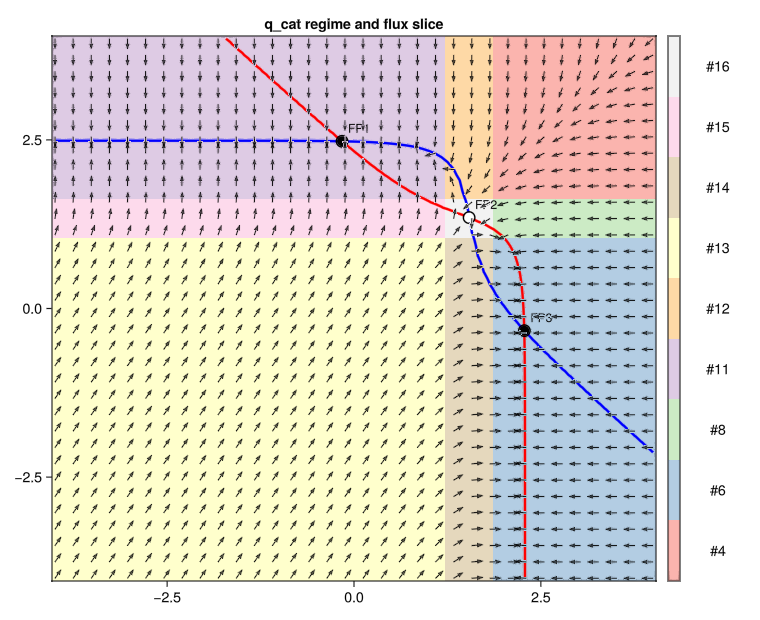

In [65]:
fig_nullcline, ax_nullcline, nullcline_data = plot_qcat_slice_with_flux(
    model_initial;
    method=:homotopy,
    wKk=p,
    ranges=(-4, 4),
    n=100,
    arrow_stride=3,
    colormap = :Pastel1_9,
    chart=:x,
    show_nullclines=true,
    fixed_point_labels=true,
)
fig_nullcline

In [56]:
unstable_rgms = filter(rgm -> !is_stable(rgm), rgms_fulldim)

3-element Vector{BindingAndCatalysis.BncRegime}:
 BncRegime(bind=[1, 6, 6, 5], cat=[3, 4, 1, 6], ss=([1, 6, 6, 5], [3, 4, 1, 6]), nullity=0, asymptotic=true)
 BncRegime(bind=[5, 2, 6, 5], cat=[3, 4, 5, 2], ss=([5, 2, 6, 5], [3, 4, 5, 2]), nullity=0, asymptotic=true)
 BncRegime(bind=[5, 6, 6, 5], cat=[3, 4, 5, 6], ss=([5, 6, 6, 5], [3, 4, 5, 6]), nullity=0, asymptotic=true)

4-element Vector{Symbolics.Num}:
 (tD₁^2.0) > (K₁*tD₂)
    (tD₂*β) > (tD₁*γ)
     (K₁*β) > (tD₁*γ)
  (K₁*tD₂) > (K₂*tD₁)

6-element Vector{Float64}:
  3.989434662727491
  3.5308662230747383
  2.566514886334459
 -0.42822552532069474
 -4.546212139127187
 -0.8521154199515002

In [ ]:
[(label="FP$(pt.idx)", logqcat=pt.logqcat, stable=pt.stable, source=pt.source) for pt in nullcline_data.fixed_points]

In [49]:
get_catalysis_regime(rgms_fulldim[r1_idx])

CatalysisRegime
  dominant mode: perm=[3, 4, 1, 2]
  nullity: 2
  asymptotic: true

In [50]:
get_catalysis_regime(rgms_fulldim[r2_idx])

CatalysisRegime
  dominant mode: perm=[3, 4, 1, 6]
  nullity: 2
  asymptotic: true

In [4]:
model2 = let 
    N = [1 1 -1]
    q_sym = [:tD₁, :tP₂]
    L = [1 0 1
         0 1 1]
    x_sym = [:D₁, :P₂, :C₂]
    Bnc(;N, q_sym, L,x_sym)
end

----------Binding Network Summary:-------------
Number of species (n): 3
Number of conserved quantities (d): 2
Number of reactions (r): 1
L matrix: sparse([1, 2, 1, 2], [1, 2, 3, 3], [1, 1, 1, 1], 2, 3)
N matrix: sparse([1, 1, 1], [1, 2, 3], [1, 1, -1], 1, 3)
Direction of binding reactions: backward
Catalysis involved: No
Regimes constructed: No
-----------------------------------------------

In [5]:
pth = SIMOPaths(model2, :tP₂)

[ Info: ---------------------Start finding all regimes--------------------
[ Info: Finished, with 4 regimes found and 4 asymptotic regimes.
[ Info: 2.Building x-neighbor regime graph...
[ Info: 3.Building regime objects...
[ Info: 4.Propagating affine data and deferred nullity labels...
[ Info: 5.Calculating qK change directions on the regime graph...
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
[ Info: Finished.
[ Info: sources: [2, 1]
[ Info: sinks: [3]
[ Info: Start enumerating paths from sources to sinks. This may take a while if there are many paths.
[ Info: Total vertices to process in topological order: 4
[ Info: Finished enumerating paths. Now collecting paths from sources. Total sources: 2


SIMOPaths object with 2 paths for qK coordinate index 2

In [6]:
summary(pth)

[ Info: Start building polyhedra for edges (total: 3)
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
[ Info: Start building polyhedra for paths (total: 2) via suffix DAG with 4 unique suffix states across 3 layers
[ Info: Suffix DAG layer 1/3: 1 states
[ Info: Suffix DAG layer 2/3: 2 states
[ Info: Suffix DAG layer 3/3: 1 states
[ Info: Number of polyhedra to calc volume: 2


Path 1         #1 → #3       Volume: 0.5014 ± 0.0022
Path 2         #2 → #4 → #3  Volume: 0.4986 ± 0.0022


[ Info: All regimes converged after 200000 samples.


In [11]:
show_expression_path(pth, 1; observe_x=:D₁)

Expression path along regimes: 1 → 3
Regime 1
  D₁ ~ tD₁
  cross 1 → 3 when
    tP₂ ~ K₁
Regime 3
  D₁ ~ (K₁*tD₁) / tP₂


In [10]:
show_condition(pth,1)

1-element Vector{Symbolics.Num}:
 K₁ > tD₁

In [15]:
judge_dstable([-1 0; -1 -1])

1

In [4]:
model2 = let 
    N = [1 1 -1]
    q_sym = [:tD₁, :tP₂]
    L = [1 0 1
         0 1 1]
    K_sym = [:K₂]
    x_sym = [:D₁, :P₂, :C₂]
    Bnc(;N, q_sym, L,K_sym, x_sym)
end
model3 = let 
    N = [1 1 -1]
    q_sym = [:tD₂, :tP₁]
    L = [1 0 1
         0 1 1]
    K_sym = [:K₁]
    x_sym = [:D₂, :P₁, :C₁]
    Bnc(;N, q_sym, L,K_sym, x_sym)
end

get_perm(a,b) = let 
    rgm1 = get_regime(model2,a)
    rgm2 = get_regime(model3,b)
    show_dominant_condition(rgm1)
    show_dominant_condition(rgm2)
    P = let 
        P1 = get_P(rgm1)
        P2 = get_P(rgm2)
        P = zeros(Int, 4, 6)
        row1 = locate_sym_qK.(Ref(model), model2.q_sym)
        col1 = locate_sym_x.(Ref(model), model2.x_sym)
        P[row1, col1] .= P1

        row2 = locate_sym_qK.(Ref(model), model3.q_sym)
        col2 = locate_sym_x.(Ref(model), model3.x_sym)
        P[row2, col2] .= P2
        P
    end
    perm = findfirst.(x->x!=0, eachrow(P))
end

get_perm (generic function with 1 method)

In [108]:
poly(rgm) = let 
    mapping_mat = let 
        [
            diagm(ones(Int,8))
            zeros(Int, 2, 4) diagm(ones(Int,2)) zeros(Int, 2, 2)
        ]
    end

    C,C0,nlt = get_C_C0_nullity_wKk(rgm)

    C_new = C * mapping_mat

    p = get_polyhedron(C_new, C0, nlt)
end

poly (generic function with 1 method)

In [69]:
show_expression_x(model2,3)

3-element Vector{Symbolics.Equation}:
 D₁ ~ (K₂*tD₁) / tP₂
 P₂ ~ tP₂
 C₂ ~ tD₁

In [70]:
show_dominant_condition(model3,4)

2-element Vector{Symbolics.Equation}:
 tD₂ ~ C₁
 tP₁ ~ C₁

In [71]:
show_expression_x(model3,1)

3-element Vector{Symbolics.Equation}:
 D₂ ~ tD₂
 P₁ ~ tP₁
 C₁ ~ (tD₂*tP₁) / K₁

In [119]:
perm = get_perm(3,2)
rgm = get_bnc_regime(model, perm,3)
p32 = poly(rgm)
show_condition_xk(rgm)

8-element Vector{Any}:
                  D₁*β₁ ~ C₁*δ₁
                  D₂*β₂ ~ P₂*γ₂
           C₁ > P₁
           P₂ > C₂
           C₂ > D₁
           D₂ > C₁
 (C₁*δ₁) > (P₁*γ₁)
 (P₂*γ₂) > (C₂*δ₂)

In [120]:
perm = get_perm(2,3)
rgm = get_bnc_regime(model, perm,2)
# show_catalysis_dynamics(rgm)
p23 = poly(rgm)
show_condition_xk(rgm)

8-element Vector{Any}:
                  D₁*β₁ ~ P₁*γ₁
                  D₂*β₂ ~ C₂*δ₂
           P₁ > C₁
           C₂ > P₂
           D₁ > C₂
           C₁ > D₂
 (P₁*γ₁) > (C₁*δ₁)
 (C₂*δ₂) > (P₂*γ₂)

In [121]:
perm = get_perm(3,1)
rgm = get_bnc_regime(model, perm,1)
p31 = poly(rgm)
show_condition_xk(rgm)

8-element Vector{Any}:
                  D₁*β₁ ~ P₁*γ₁
                  D₂*β₂ ~ P₂*γ₂
           P₁ > C₁
           P₂ > C₂
           C₂ > D₁
           D₂ > C₁
 (P₁*γ₁) > (C₁*δ₁)
 (P₂*γ₂) > (C₂*δ₂)

In [122]:
perm = get_perm(1,3)
rgm = get_bnc_regime(model, perm,1)
p13 = poly(rgm)
show_condition_xk(rgm)

8-element Vector{Any}:
                  D₁*β₁ ~ P₁*γ₁
                  D₂*β₂ ~ P₂*γ₂
           P₁ > C₁
           P₂ > C₂
           D₁ > C₂
           C₁ > D₂
 (P₁*γ₁) > (C₁*δ₁)
 (P₂*γ₂) > (C₂*δ₂)

In [128]:
calc_volume(p23, rel_tol=1e-3)

[ Info: Number of polyhedra to calc volume: 1
[ Info: All regimes converged after 13000000 samples.


Volume(Mean=2.293e-01, STD=2.285e-04, RelError=0.10%)

In [123]:
new_sym = wKk_sym(model)[1:8]

8-element Vector{Symbolics.Num}:
 tD₁
 tD₂
  K₁
  K₂
  γ₁
  γ₂
  β₁
  β₂

In [124]:
show_condition_poly(p13,syms=new_sym)

4-element Vector{Symbolics.Num}:
                        K₂ > tD₁
 (K₂*tD₁*β₁*γ₂) > (K₁*tD₂*β₂*γ₁)
              (tD₁*β₁) > (K₁*γ₁)
             (tD₁*β₁) > (tD₂*γ₁)

In [78]:
show_catalysis_dynamics(model)

4-element Vector{Symbolics.Equation}:
 Differential(t, 1)(tP₁) ~ -C₁*δ₁ + D₁*β₁ - P₁*γ₁
 Differential(t, 1)(tP₂) ~ -C₂*δ₂ + D₂*β₂ - P₂*γ₂
 Differential(t, 1)(tD₁) ~ 0
 Differential(t, 1)(tD₂) ~ 0

In [79]:
show_catalysis_dynamics(rgm)

4-element Vector{Symbolics.Equation}:
 Differential(t, 1)(tP₁) ~ tD₁*β₁ - tP₁*γ₁
 Differential(t, 1)(tP₂) ~ (K₁*tD₂*β₂) / tP₁ - tP₂*δ₂
 Differential(t, 1)(tD₁) ~ 0
 Differential(t, 1)(tD₂) ~ 0

In [80]:
show_condition_wKk(rgm)

6-element Vector{Symbolics.Num}:
                   (tD₁*β₁) > (tD₂*γ₁)
                              tD₁ > K₂
 ((tD₁^(2//1))*β₁*δ₂) > (K₁*tD₂*β₂*γ₁)
                    (tD₁*β₁) > (K₁*γ₁)
                   (tD₁*β₁) > (tD₂*δ₁)
                    (tD₁*δ₂) > (K₂*γ₂)

In [51]:
C0

6-element Vector{ExactLogExpr}:
 0
 0
 0
 0
 0
 0

In [37]:
get_H_bd(rgm)

2×2 SparseMatrixCSC{Float64, Int64} with 2 stored entries:
 -1.0   ⋅ 
 -1.0   ⋅ 

In [31]:
show_catalysis_dynamics(rgm)

4-element Vector{Symbolics.Equation}:
 Differential(t, 1)(tP₁) ~ tD₁*β₁ - tP₁*γ₁
 Differential(t, 1)(tP₂) ~ (K₁*tD₂*β₂) / tP₁ - tP₂*γ₂
 Differential(t, 1)(tD₁) ~ 0
 Differential(t, 1)(tD₂) ~ 0

In [81]:
wKk_sym(rgm)

10-element Vector{Symbolics.Num}:
 tD₁
 tD₂
  K₁
  K₂
  γ₁
  γ₂
  β₁
  β₂
  δ₁
  δ₂

In [87]:
diagm(ones(Int,8))

8×8 Matrix{Int64}:
 1  0  0  0  0  0  0  0
 0  1  0  0  0  0  0  0
 0  0  1  0  0  0  0  0
 0  0  0  1  0  0  0  0
 0  0  0  0  1  0  0  0
 0  0  0  0  0  1  0  0
 0  0  0  0  0  0  1  0
 0  0  0  0  0  0  0  1

In [142]:
p_case3 = intersect(p23,p32)
removehredundancy!(p_case3)
show_condition_poly(p_case3, syms=new_sym)

6-element Vector{Symbolics.Num}:
 ((tD₁^2.0)*β₁*γ₂) > (K₁*tD₂*β₂*γ₁)
                (tD₁*β₁) > (tD₂*γ₁)
                           tD₁ > K₂
                (tD₂*β₂) > (tD₁*γ₂)
 ((tD₂^2.0)*β₂*γ₁) > (K₂*tD₁*β₁*γ₂)
                           tD₂ > K₁

In [144]:
v_case3 = calc_volume(p_case3, rel_tol=1e-3)

[ Info: Number of polyhedra to calc volume: 1
[ Info: All regimes converged after 148900000 samples.


Volume(Mean=2.516e-02, STD=2.516e-05, RelError=0.10%)

In [140]:
p_case1 = intersect(p23,p31)
removehredundancy!(p_case1)


4-element Vector{Symbolics.Num}:
 ((tD₁^2.0)*β₁*γ₂) > (K₁*tD₂*β₂*γ₁)
                (tD₂*β₂) > (tD₁*γ₂)
    (K₁*tD₂*β₂*γ₁) > (K₂*tD₁*β₁*γ₂)
                           K₁ > tD₂

In [145]:
v_case1 = calc_volume(p_case1, rel_tol=1e-3)

[ Info: Number of polyhedra to calc volume: 1
[ Info: All regimes converged after 547300000 samples.


Volume(Mean=6.970e-03, STD=6.970e-06, RelError=0.10%)

In [146]:
C_case1 = get_C(p_case1)
C_case3 = get_C(p_case3)

6×8 SparseMatrixCSC{Float64, Int64} with 26 stored entries:
  2.0  -1.0  -1.0    ⋅   -1.0   1.0   1.0  -1.0
  1.0  -1.0    ⋅     ⋅   -1.0    ⋅    1.0    ⋅ 
  1.0    ⋅     ⋅   -1.0    ⋅     ⋅     ⋅     ⋅ 
 -1.0   1.0    ⋅     ⋅     ⋅   -1.0    ⋅    1.0
 -1.0   2.0    ⋅   -1.0   1.0  -1.0  -1.0   1.0
   ⋅    1.0  -1.0    ⋅     ⋅     ⋅     ⋅     ⋅ 

In [149]:
pnew = get_polyhedron(vcat(C_case3[1:5,:], C_case1[1:3,:]),zeros(Int, 8),0)

Polyhedron CDDLib.Polyhedron{Float64}:
5-element iterator of HalfSpace{Float64, Vector{Float64}}:
 HalfSpace([-1.0, 1.0, 0.0, 0.0, 1.0, 0.0, -1.0, 0.0], 0.0)
 HalfSpace([1.0, -1.0, 0.0, 0.0, 0.0, 1.0, 0.0, -1.0], 0.0)
 HalfSpace([1.0, -2.0, 0.0, 1.0, -1.0, 1.0, 1.0, -1.0], 0.0)
 HalfSpace([-2.0, 1.0, 1.0, 0.0, 1.0, -1.0, -1.0, 1.0], 0.0)
 HalfSpace([1.0, -1.0, -1.0, 1.0, -1.0, 1.0, 1.0, -1.0], 0.0)

In [150]:
v_new = calc_volume(pnew)

[ Info: Number of polyhedra to calc volume: 1
[ Info: All regimes converged after 9200000 samples.


Volume(Mean=1.645e-02, STD=8.220e-05, RelError=0.50%)

In [154]:
v_case1 *2 +v_case3

Volume(Mean=3.910e-02, STD=2.876e-05, RelError=0.07%)

In [153]:
v_case3

Volume(Mean=2.516e-02, STD=2.516e-05, RelError=0.10%)

In [164]:
#P1 P2 D1 D2 C1 C2
model = let 
    N = [
        # :P₁, :P₂, :D₁, :D₂, :Cₚ₁, :Cₚ₂, :C₁, :C₂]
           2    0    0    0    -1    0    0     0
           0    2    0    0     0   -1    0     0   
           0    0    0   1      1    0    -1     0 
           0    0    1    0     0     1    0     -1
         ]
    x_sym = [:P₁, :P₂, :D₁, :D₂, :Cₚ₁, :Cₚ₂, :C₁, :C₂]
    q_sym = [:tP₁, :tP₂, :tD₁, :tD₂]
    K_sym = [:Kₚ₁, :Kₚ₂, :K₁, :K₂]
    Bnc(;N, x_sym, q_sym, K_sym)
end


----------Binding Network Summary:-------------
Number of species (n): 8
Number of conserved quantities (d): 4
Number of reactions (r): 4
L matrix: sparse([1, 2, 3, 4, 1, 2, 1, 4, 2, 3], [1, 2, 3, 4, 5, 6, 7, 7, 8, 8], [1, 1, 1, 1, 2, 2, 2, 1, 2, 1], 4, 8)
N matrix: sparse([1, 2, 4, 3, 1, 3, 2, 4, 3, 4], [1, 2, 3, 4, 5, 5, 6, 6, 7, 8], [2, 2, 1, 1, -1, 1, -1, 1, -1, -1], 4, 8)
Direction of binding reactions: forward
Catalysis involved: No
Regimes constructed: No
-----------------------------------------------

In [157]:
let 
    Π = diagm(ones(Int, 8))
    S = [-1 0 1 0 -1 0 -1 0
          0 -1 0 1 0 -1 0 -1]
    update_catalysis!(model; Π, Γ=S, q_picked=[1,2],k_sym = [:γ₁, :γ₂, :β₁, :β₂, :γ₁, :γ₂, :γ₁, :γ₂])
end

[ Info: q is reordered to make catalysis-involving species first


In [158]:
find_all_regimes!(model)

[ Info: ---------------------Start finding all regimes--------------------
[ Info: Finished, with 36 regimes found and 36 asymptotic regimes.
[ Info: 2.Building x-neighbor regime graph...
[ Info: 3.Building regime objects...
[ Info: 4.Propagating affine data and deferred nullity labels...
[ Info: 5.Calculating qK change directions on the regime graph...
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
[ Info: Finished.


In [159]:
show_catalysis_dynamics(model)
show_conservation(model)
show_equilibrium(model)

4-element Vector{Symbolics.Equation}:
 Kₚ₁ ~ (P₁^2) / Cₚ₁
 Kₚ₂ ~ (P₂^2) / Cₚ₂
 K₁ ~ (Cₚ₂*D₁) / C₁
 K₂ ~ (Cₚ₁*D₂) / C₂

In [3]:
model2 = let 
    N = [
        # :P₁,  :D₂, :Cₚ₁,  :C₁]
           2      0    -1      0
           0      1    1       -1
         ]
    x_sym = [:P₁, :D₂, :Cₚ₁,  :C₁]
    q_sym = [:tP₁, :tD₂]
    K_sym = [:Kₚ₁, :K₂]
    Bnc(;N, x_sym, q_sym, K_sym)
end

model3 = let 
    N = [
           2      0    -1      0
           0      1    1       -1
         ]
    x_sym = [:P₂, :D₁, :Cₚ₂,  :C₂]
    q_sym = [:tP₂, :tD₁]
    K_sym = [:Kₚ₂, :K₁]
    Bnc(;N, x_sym, q_sym, K_sym)
end

----------Binding Network Summary:-------------
Number of species (n): 4
Number of conserved quantities (d): 2
Number of reactions (r): 2
L matrix: sparse([1, 2, 1, 1, 2], [1, 2, 3, 4, 4], [1, 1, 2, 2, 1], 2, 4)
N matrix: sparse([1, 2, 1, 2, 2], [1, 2, 3, 3, 4], [2, 1, -1, 1, -1], 2, 4)
Direction of binding reactions: forward
Catalysis involved: No
Regimes constructed: No
-----------------------------------------------

In [4]:
pth = SIMOPaths(model3, :tP₂)

[ Info: ---------------------Start finding all regimes--------------------
[ Info: Finished, with 6 regimes found and 6 asymptotic regimes.
[ Info: 2.Building x-neighbor regime graph...
[ Info: 3.Building regime objects...
[ Info: 4.Propagating affine data and deferred nullity labels...
[ Info: 5.Calculating qK change directions on the regime graph...
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
[ Info: Finished.
[ Info: sources: [1]
[ Info: sinks: [4]
[ Info: Start enumerating paths from sources to sinks. This may take a while if there are many paths.
[ Info: Total vertices to process in topological order: 6
[ Info: Finished enumerating paths. Now collecting paths from sources. Total sources: 1


SIMOPaths object with 4 paths for qK coordinate index 1

In [5]:
summary(pth)

[ Info: Start building polyhedra for edges (total: 8)
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
[ Info: Start building polyhedra for paths (total: 4) via suffix DAG with 11 unique suffix states across 5 layers
[ Info: Suffix DAG layer 1/5: 1 states
[ Info: Suffix DAG layer 2/5: 3 states
[ Info: Suffix DAG layer 3/5: 4 states
[ Info: Suffix DAG layer 4/5: 2 states
[ Info: Suffix DAG layer 5/5: 1 states
[ Info: Number of polyhedra to calc volume: 4


Path 1         #1 → #2 → #4            Volume: 0.2504 ± 0.0012
Path 2         #1 → #3 → #4            Volume: 0.3319 ± 0.0015


[ Info: All regimes converged after 1700000 samples.


Path 3         #1 → #5 → #6 → #2 → #4  Volume: 0.0833 ± 0.0004
Path 4         #1 → #5 → #6 → #4       Volume: 0.3346 ± 0.0015


In [6]:
summary_RO_path(pth, observe_x=:D₁, deduplicate=false)

Path [4]       0 → 0 → -Inf → -1       Volume: 0.3346 ± 0.0015
Path [2]       0 → 0 → -1              Volume: 0.3319 ± 0.0015
Path [1]       0 → -2 → -1             Volume: 0.2504 ± 0.0012
Path [3]       0 → 0 → -Inf → -2 → -1  Volume: 0.0833 ± 0.0004


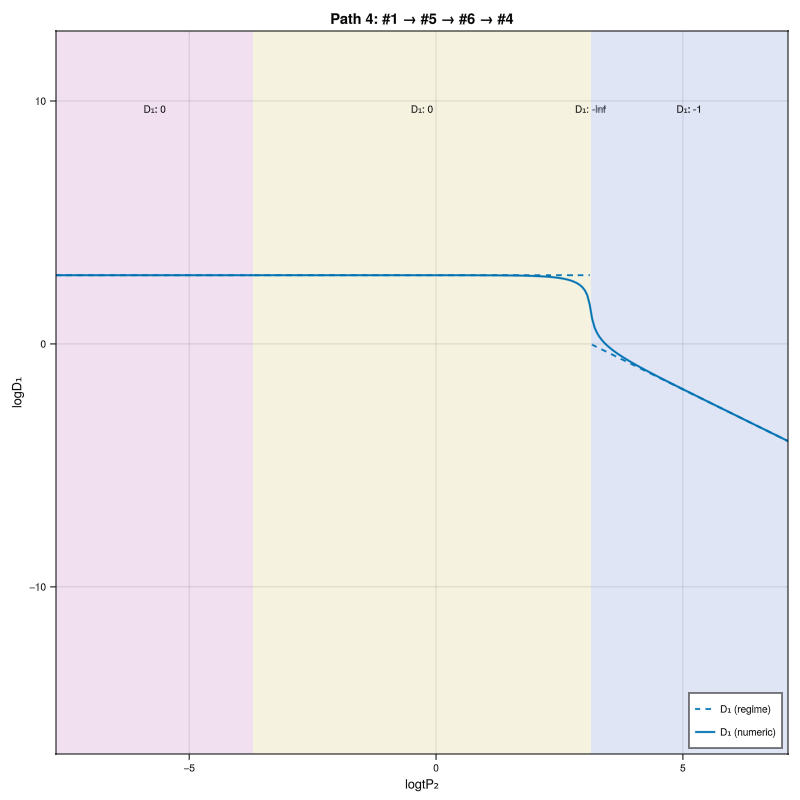

In [7]:
f = SISO_plot(pth,4; observe_x=:D₁,size= (800,800),pad = 4)